/var/folders/n0/q76k2fl902l89_80wvtgb81r0000gn/T/ipykernel_2265/1026010065.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = data = pd.read_csv(filename, delim_whitespace=True)
/var/folders/n0/q76k2fl902l89_80wvtgb81r0000gn/T/ipykernel_2265/1026010065.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_IA = pd.read_csv(filename_IA, delim_whitespace=True)


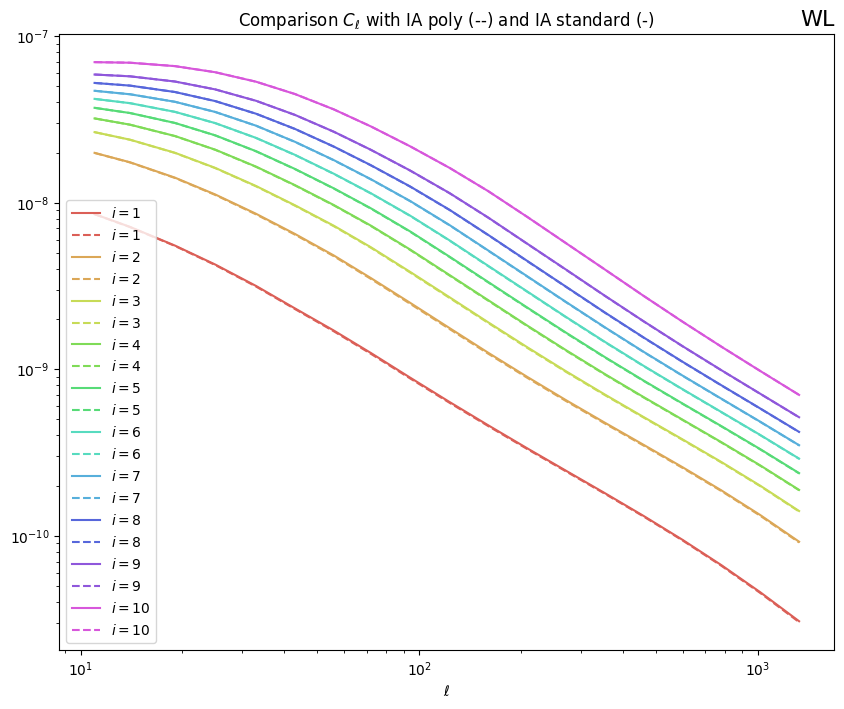

<Figure size 640x480 with 0 Axes>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn           as sb
import pandas as pd

# Step 1: Load the data
filename = './mock_data/LCDM_test_galonly_Cls_noiseless.dat'
data = data = pd.read_csv(filename, delim_whitespace=True)
filename_IA= './mock_data/LCDM_test_galonly_IApoly_Cls_noiseless.dat'
data_IA = pd.read_csv(filename_IA, delim_whitespace=True)
# Assuming the data has two columns: x and y
ells = data['ells'].values
Nbins_wl = len([col for col in data.columns if col.startswith('L')])

bincolors = sb.color_palette('hls',11)
norm = ells * (ells + 1) / (2 * np.pi)

plt.figure(figsize=(10, 8))
plt.title('WL', loc='right', fontdict={'fontsize': 16})

for i in range(1, 11):
    col_name = 'L{}xL{}'.format(i, i)
    plt.plot(ells, data[col_name].values,
             label=r'$i={}$'.format(i), color=bincolors[i - 1])
    plt.plot(ells, data_IA[col_name].values,
             label=r'$i={}$'.format(i), color=bincolors[i - 1], ls='--')

plt.xlabel(r'$\ell$')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.title('Comparison $C_\ell$ with IA poly (--) and IA standard (-)')
plt.show()
plt.savefig('Cls_IA.pdf', bbox_inches='tight')


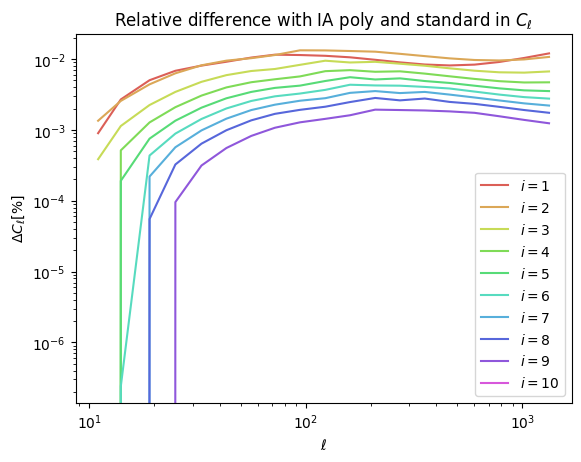

In [4]:
for i in range(1, 11):
    col_name = 'L{}xL{}'.format(i, i)
    plt.plot(ells, (data[col_name].values-data_IA[col_name].values)/data[col_name].values,
             label=r'$i={}$'.format(i), color=bincolors[i - 1])

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\Delta C_\ell [\%]$')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.xscale('log')
plt.yscale('log')
plt.title('Relative difference with IA poly and standard in $C_{\ell}$')
plt.legend()

plt.savefig('Cls_IA.pdf', bbox_inches='tight')
plt.show()